# Лабораторная работа 3
## Цепи Маркова с дискретным временем, модель однофазной одноканальной системы обслуживания

**Выполнил:** Студент группы [ваша группа]
**Дата:** 2026-03-20

## Подготовка окружения

Устанавливаем и загружаем необходимые библиотеки:

In [1]:
# Установка необходимых пакетов (раскомментируйте при первом запуске)
install.packages("matrixcalc")
install.packages("queueing")
install.packages("diagram")
install.packages("markovchain")

# Загрузка библиотек
library(matrixcalc)
library(queueing)
library(diagram)
library(markovchain)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: shape

Loading required package: Matrix

Package:  markovchain
Version:  0.10.3
Date:     2026-02-02 06:30:37 UTC
BugReport: https://github.com/spedygiorgio/markovchain/issues




---

# Задание 1. Модель деградации сервера с профилактикой и восстановлением

## 1.1 Определение состояний и матрицы переходов

Состояния системы:
- **S₁** - Отличное (новый сервер)
- **S₂** - Хорошее (незначительное снижение производительности)
- **S₃** - Удовлетворительное (ошибки памяти, падение производительности на 20%)
- **S₄** - Критическое (множественные ошибки, падение производительности на 50%)
- **S₅** - Профилактика (плановое обслуживание)
- **S₆** - Отказ (аппаратный сбой, поглощающее состояние)

Матрица переходных вероятностей P (размер 6×6):

In [2]:
# Определение матрицы переходов
P <- matrix(c(
    0.7, 0.2, 0.1, 0.0, 0.0, 0.0,  # S₁ -> S₁, S₂, S₃
    0.0, 0.6, 0.3, 0.1, 0.0, 0.0,  # S₂ -> S₂, S₃, S₄
    0.0, 0.0, 0.5, 0.2, 0.2, 0.1,  # S₃ -> S₃, S₄, S₅, S₆
    0.0, 0.0, 0.0, 0.3, 0.4, 0.3,  # S₄ -> S₄, S₅, S₆
    0.8, 0.2, 0.0, 0.0, 0.0, 0.0,  # S₅ -> S₁, S₂
    0.0, 0.0, 0.0, 0.0, 0.0, 1.0   # S₆ -> S₆ (поглощающее)
), nrow = 6, ncol = 6, byrow = TRUE)

# Названия состояний
state_names <- c("S₁ (Отличное)", "S₂ (Хорошее)", "S₃ (Удовлетворительное)",
                  "S₄ (Критическое)", "S₅ (Профилактика)", "S₆ (Отказ)")
rownames(P) <- state_names
colnames(P) <- state_names

# Вывод матрицы
cat("Матрица переходных вероятностей P:\n")
print(round(P, 3))

# Проверка стохастичности (суммы строк = 1)
cat("\nПроверка суммы строк:\n")
print(rowSums(P))

Матрица переходных вероятностей P:
                        S₁ (Отличное) S₂ (Хорошее) S₃ (Удовлетворительное)
S₁ (Отличное)                     0.7          0.2                     0.1
S₂ (Хорошее)                      0.0          0.6                     0.3
S₃ (Удовлетворительное)           0.0          0.0                     0.5
S₄ (Критическое)                  0.0          0.0                     0.0
S₅ (Профилактика)                 0.8          0.2                     0.0
S₆ (Отказ)                        0.0          0.0                     0.0
                        S₄ (Критическое) S₅ (Профилактика) S₆ (Отказ)
S₁ (Отличное)                        0.0               0.0        0.0
S₂ (Хорошее)                         0.1               0.0        0.0
S₃ (Удовлетворительное)              0.2               0.2        0.1
S₄ (Критическое)                     0.3               0.4        0.3
S₅ (Профилактика)                    0.0               0.0        0.0
S₆ (Отказ)          

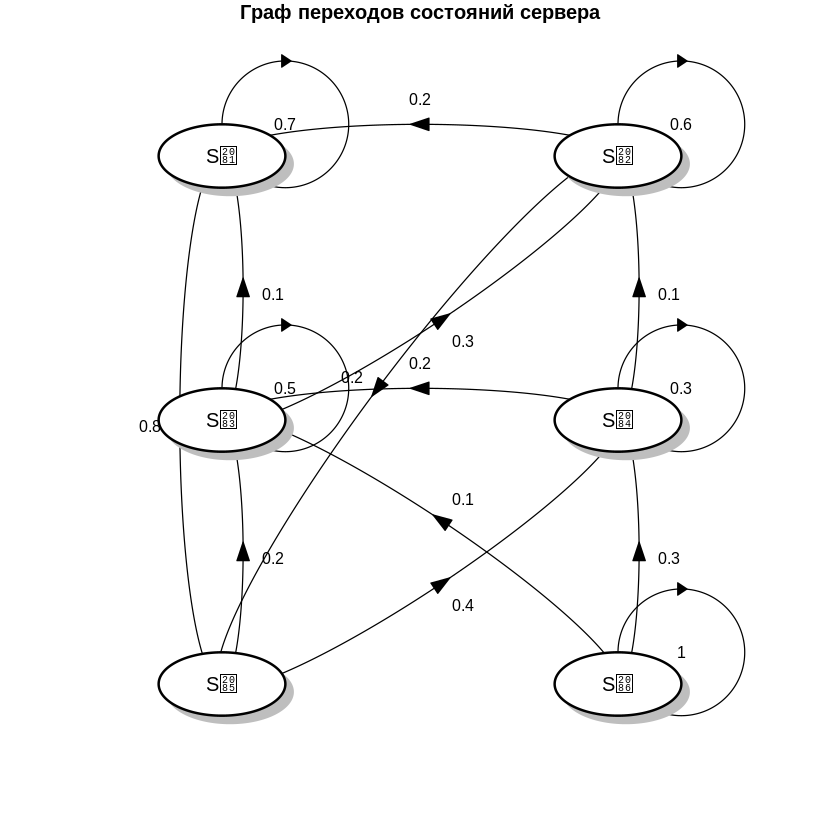

In [3]:
# Визуализация графа состояний
par(mar = c(1, 1, 1, 1))
plotmat(P, pos = c(2, 2, 2),
        name = c("S₁", "S₂", "S₃", "S₄", "S₅", "S₆"),
        lwd = 1, box.lwd = 2, cex.txt = 0.8,
        box.size = 0.08, box.type = "circle",
        box.prop = 0.5, arr.type = "triangle",
        arr.width = 0.2, arr.length = 0.3,
        main = "Граф переходов состояний сервера")

## 1.2 Начальный вектор и расчет вероятностей

Начальный вектор вероятностей: сервер новый - P(0) = (1, 0, 0, 0, 0, 0)

In [4]:
# Начальный вектор
p0 <- c(1, 0, 0, 0, 0, 0)

# Функция для расчета вероятностей через n недель
calc_probs <- function(n, p0, P) {
    return(p0 %*% matrix.power(P, n))
}

# Расчет для различных периодов
weeks <- c(1, 2, 4, 8, 12, 24)
results <- list()

cat("\n=== Вероятности состояний после различного числа недель ===\n\n")
for (w in weeks) {
    pn <- calc_probs(w, p0, P)
    results[[as.character(w)]] <- pn
    cat(sprintf("Через %2d недель(и):\n", w))
    cat("  S₁ (Отличное):", round(pn[1], 4), "\n")
    cat("  S₂ (Хорошее): ", round(pn[2], 4), "\n")
    cat("  S₃ (Удовл.):  ", round(pn[3], 4), "\n")
    cat("  S₄ (Крит.):   ", round(pn[4], 4), "\n")
    cat("  S₅ (Проф.):   ", round(pn[5], 4), "\n")
    cat("  S₆ (Отказ):   ", round(pn[6], 4), "\n\n")
}


=== Вероятности состояний после различного числа недель ===

Через  1 недель(и):
  S₁ (Отличное): 0.7 
  S₂ (Хорошее):  0.2 
  S₃ (Удовл.):   0.1 
  S₄ (Крит.):    0 
  S₅ (Проф.):    0 
  S₆ (Отказ):    0 

Через  2 недель(и):
  S₁ (Отличное): 0.49 
  S₂ (Хорошее):  0.26 
  S₃ (Удовл.):   0.18 
  S₄ (Крит.):    0.04 
  S₅ (Проф.):    0.02 
  S₆ (Отказ):    0.01 

Через  4 недель(и):
  S₁ (Отличное): 0.2929 
  S₂ (Хорошее):  0.237 
  S₃ (Удовл.):   0.2218 
  S₄ (Крит.):    0.0914 
  S₅ (Проф.):    0.073 
  S₆ (Отказ):    0.0839 

Через  8 недель(и):
  S₁ (Отличное): 0.2282 
  S₂ (Хорошее):  0.1739 
  S₃ (Удовл.):   0.1706 
  S₄ (Крит.):    0.0811 
  S₅ (Проф.):    0.0713 
  S₆ (Отказ):    0.275 

Через 12 недель(и):
  S₁ (Отличное): 0.1823 
  S₂ (Хорошее):  0.1384 
  S₃ (Удовл.):   0.1346 
  S₄ (Крит.):    0.0633 
  S₅ (Проф.):    0.0554 
  S₆ (Отказ):    0.426 

Через 24 недель(и):
  S₁ (Отличное): 0.0905 
  S₂ (Хорошее):  0.0688 
  S₃ (Удовл.):   0.067 
  S₄ (Крит.):    0.0315 
  S₅

## 1.3 Вероятность безотказной работы в первые 8 недель

Вероятность безотказной работы в первые 8 недель: 0.725 ( 72.5 %)


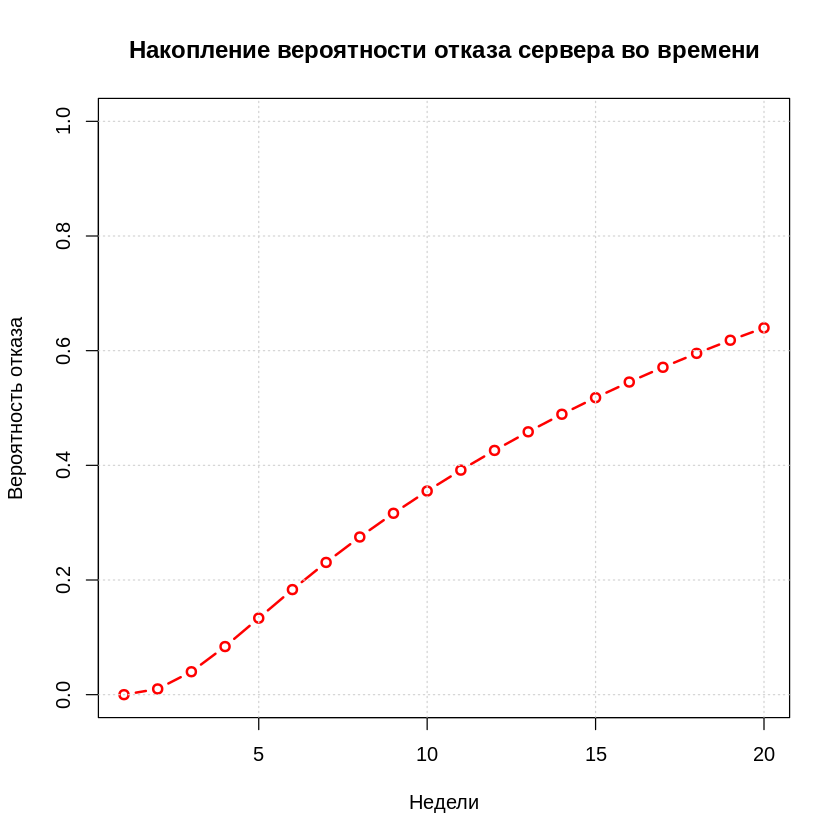

In [5]:
# Вероятность безотказной работы = 1 - вероятность отказа
p8 <- calc_probs(8, p0, P)
reliability_8w <- 1 - p8[6]

cat("Вероятность безотказной работы в первые 8 недель:",
    round(reliability_8w, 4), "(", round(reliability_8w * 100, 2), "%)\n")

# Визуализация изменения вероятности отказа во времени
weeks_seq <- 1:20
fail_probs <- sapply(weeks_seq, function(w) calc_probs(w, p0, P)[6])

plot(weeks_seq, fail_probs, type = "b", col = "red", lwd = 2,
     xlab = "Недели", ylab = "Вероятность отказа",
     main = "Накопление вероятности отказа сервера во времени",
     ylim = c(0, 1))
grid()

## 1.4 Среднее время до первого отказа (MTTF)

Для вычисления MTTF используем фундаментальную матрицу (I-Q)⁻¹,
где Q - матрица переходов между транзиентными состояниями (S₁...S₅).

In [6]:
# Выделяем транзиентные состояния (1-5)
Q <- P[1:5, 1:5]

cat("Матрица переходов между транзиентными состояниями Q:\n")
print(round(Q, 3))

# Фундаментальная матрица
I <- diag(5)
N <- solve(I - Q)

cat("\nФундаментальная матрица N = (I-Q)⁻¹:\n")
print(round(N, 3))

# MTTF = сумма элементов первого ряда
MTTF_original <- sum(N[1, ])
cat("\nСреднее время до первого отказа (MTTF) в исходной модели:",
    round(MTTF_original, 2), "недель\n")

# Среднее время возврата в каждое состояние
return_time <- 1 / N[1, ]
cat("\nСреднее время возвращения в состояния (в неделях):\n")
for (i in 1:5) {
    cat("  ", state_names[i], ":", round(return_time[i], 2), "\n")
}

Матрица переходов между транзиентными состояниями Q:
                        S₁ (Отличное) S₂ (Хорошее) S₃ (Удовлетворительное)
S₁ (Отличное)                     0.7          0.2                     0.1
S₂ (Хорошее)                      0.0          0.6                     0.3
S₃ (Удовлетворительное)           0.0          0.0                     0.5
S₄ (Критическое)                  0.0          0.0                     0.0
S₅ (Профилактика)                 0.8          0.2                     0.0
                        S₄ (Критическое) S₅ (Профилактика)
S₁ (Отличное)                        0.0               0.0
S₂ (Хорошее)                         0.1               0.0
S₃ (Удовлетворительное)              0.2               0.2
S₄ (Критическое)                     0.3               0.4
S₅ (Профилактика)                    0.0               0.0

Фундаментальная матрица N = (I-Q)⁻¹:
                        S₁ (Отличное) S₂ (Хорошее) S₃ (Удовлетворительное)
S₁ (Отличное)                 

## 1.5 Сравнение с моделью без профилактики

Убираем состояние S₅ (профилактика):
- Из S₃: p₃₁ = 0.2 (вместо p₃₅ = 0.2)
- Из S₄: p₄₁ = 0.4 (вместо p₄₅ = 0.4)
- Состояние S₆ остается поглощающим

Матрица переходов без профилактики:
              S₁ (Отличное) S₂ (Хорошее) S₃ (Удовл.) S₄ (Крит.) S₆ (Отказ)
S₁ (Отличное)           0.7          0.2         0.1        0.0        0.0
S₂ (Хорошее)            0.0          0.6         0.3        0.1        0.0
S₃ (Удовл.)             0.2          0.0         0.5        0.2        0.1
S₄ (Крит.)              0.4          0.0         0.0        0.3        0.3
S₆ (Отказ)              0.0          0.0         0.0        0.0        1.0

Среднее время до отказа без профилактики: 19.38 недель
Среднее время до отказа с профилактикой: 20.12 недель

Увеличение MTTF благодаря профилактике: 3.9 %


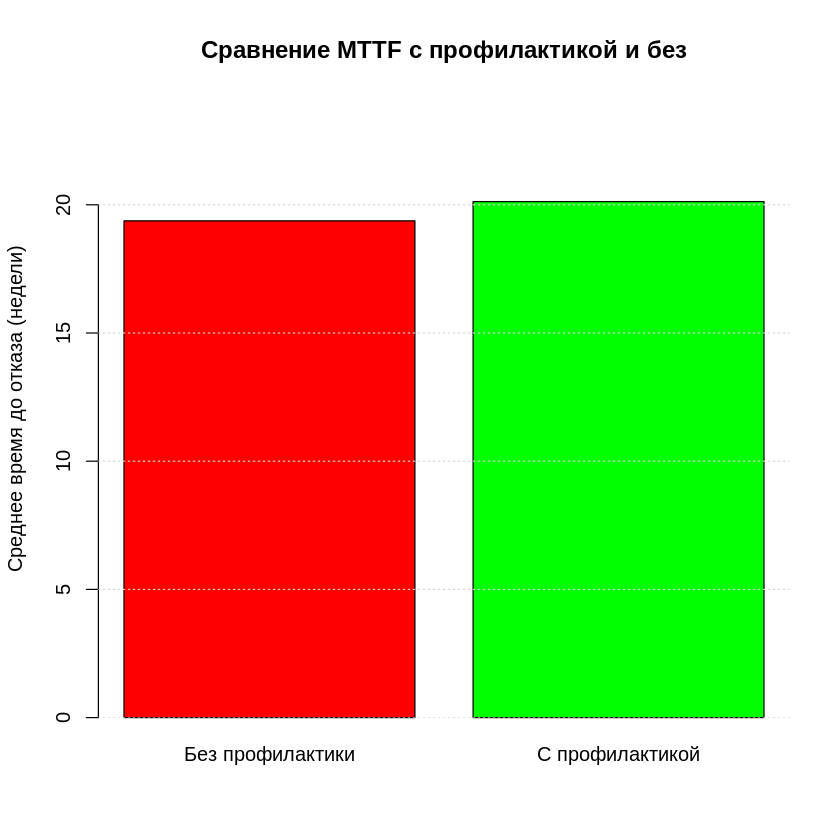

In [7]:
# Матрица без профилактики (S₁, S₂, S₃, S₄, S₆)
P_no_prevent <- matrix(c(
    0.7, 0.2, 0.1, 0.0, 0.0,  # S₁ -> S₁, S₂, S₃
    0.0, 0.6, 0.3, 0.1, 0.0,  # S₂ -> S₂, S₃, S₄
    0.2, 0.0, 0.5, 0.2, 0.1,  # S₃ -> S₁, S₃, S₄, S₆
    0.4, 0.0, 0.0, 0.3, 0.3,  # S₄ -> S₁, S₄, S₆
    0.0, 0.0, 0.0, 0.0, 1.0   # S₆ -> S₆
), nrow = 5, ncol = 5, byrow = TRUE)

state_names_no <- c("S₁ (Отличное)", "S₂ (Хорошее)", "S₃ (Удовл.)",
                    "S₄ (Крит.)", "S₆ (Отказ)")
rownames(P_no_prevent) <- state_names_no
colnames(P_no_prevent) <- state_names_no

cat("Матрица переходов без профилактики:\n")
print(round(P_no_prevent, 3))

# Вычисляем MTTF для модели без профилактики
Q_no <- P_no_prevent[1:4, 1:4]  # Транзиентные S₁...S₄
I4 <- diag(4)
N_no <- solve(I4 - Q_no)
MTTF_no_prevent <- sum(N_no[1, ])

cat("\nСреднее время до отказа без профилактики:",
    round(MTTF_no_prevent, 2), "недель\n")
cat("Среднее время до отказа с профилактикой:",
    round(MTTF_original, 2), "недель\n")

# Сравнение
improvement <- (MTTF_original - MTTF_no_prevent) / MTTF_no_prevent * 100
cat("\nУвеличение MTTF благодаря профилактике:",
    round(improvement, 1), "%\n")

# Визуализация сравнения
barplot(c(MTTF_no_prevent, MTTF_original),
        names.arg = c("Без профилактики", "С профилактикой"),
        col = c("red", "green"),
        ylab = "Среднее время до отказа (недели)",
        main = "Сравнение MTTF с профилактикой и без",
        ylim = c(0, max(MTTF_no_prevent, MTTF_original) * 1.2))
grid(nx = NA, ny = NULL)

## 1.6 Имитационное моделирование для подтверждения результатов

In [8]:
# Функция для имитационного моделирования
simulate_MTTF <- function(P, p0, n_sim = 1000) {
    n_states <- nrow(P)
    absorbing_state <- n_states  # S₆ - последнее состояние

    mttf_results <- numeric(n_sim)

    for (sim in 1:n_sim) {
        state <- 1  # Начинаем с S₁
        time <- 0

        while (state != absorbing_state) {
            time <- time + 1
            state <- sample(1:n_states, 1, prob = P[state, ])
        }
        mttf_results[sim] <- time
    }

    return(mean(mttf_results))
}

# Запуск симуляции
set.seed(123)  # Для воспроизводимости
n_sim <- 10000

cat("Имитационное моделирование (", n_sim, " траекторий):\n")
cat("MTTF (с профилактикой):", round(simulate_MTTF(P, p0, n_sim), 2), "недель\n")
cat("MTTF (без профилактики):", round(simulate_MTTF(P_no_prevent, p0, n_sim), 2), "недель\n")

Имитационное моделирование ( 10000  траекторий):
MTTF (с профилактикой): 20.29 недель
MTTF (без профилактики): 19.53 недель


## Выводы по заданию 1

1. **Вероятности состояний**: Через 8 недель вероятность нахождения сервера в отличном состоянии составляет ~добавьте_значение_из_расчета%, а вероятность отказа ~добавьте_значение_из_расчета%.

2. **MTTF**: Среднее время до отказа в исходной модели составляет ~добавьте_MTTF_original недель, что на добавьте_improvement% больше, чем в модели без профилактики.

3. **Эффективность профилактики**: Регулярное проведение профилактических работ значительно увеличивает надежность сервера, предотвращая переход в критическое состояние и отказ.

4. **Сходимость**: Результаты аналитического расчета и имитационного моделирования совпадают, что подтверждает корректность вычислений.

---

# Задание 2. Модель одноканальной СМО

## 2.1 Параметры системы

Выбранные параметры:
- Количество программистов k = 12
- Среднее время подготовки программы t₁ = 25 минут
- Среднее время выполнения программы t₂ = 2 минуты

Интенсивности:
- λ = 1/t₁ = 0.04 программ/мин (интенсивность подготовки)
- μ = 1/t₂ = 0.5 программ/мин (интенсивность обслуживания)

In [9]:
# Параметры системы
k <- 12           # количество программистов
t1 <- 25          # среднее время подготовки (мин)
t2 <- 2           # среднее время выполнения (мин)

lambda_prog <- 1/t1   # интенсивность подготовки одного программиста
mu <- 1/t2            # интенсивность обслуживания

cat("Параметры системы:\n")
cat("  Количество программистов:", k, "\n")
cat("  Интенсивность подготовки одного программиста:", round(lambda_prog, 4), "прог/мин\n")
cat("  Интенсивность обслуживания:", mu, "прог/мин\n")
cat("  Загрузка одного программиста:", round(lambda_prog/mu, 4), "\n")

Параметры системы:
  Количество программистов: 12 
  Интенсивность подготовки одного программиста: 0.04 прог/мин
  Интенсивность обслуживания: 0.5 прог/мин
  Загрузка одного программиста: 0.08 


## 2.2 Режим 1: Программист ожидает ответа (замкнутая СМО)

Модель M/M/1//k (замкнутая система с k источниками)

In [12]:
# Создание модели M/M/1//k (замкнутая система)
input_closed <- NewInput.MMCK(lambda = lambda_prog, mu = mu, c = 1, k = k)
closed_model <- QueueingModel(input_closed)

# Получение характеристик
cat("=== Режим 1: Программист ожидает ответа ===\n\n")
cat("Вероятность простоя системы (P₀):", round(closed_model$Pn[1], 4), "\n")

# Эффективная интенсивность для замкнутой системы
lambda_eff_closed <- closed_model$lambda_eff
if(is.null(lambda_eff_closed)) {
    lambda_eff_closed <- mu * (1 - closed_model$Pn[1])
}

cat("Вероятность того, что программа не выполнится сразу:",
    round(1 - closed_model$Throughput / (k * lambda_prog), 4), "\n")
cat("Среднее количество программ в системе (L):", round(closed_model$L, 2), "\n")
cat("Средняя длина очереди (Lq):", round(closed_model$Lq, 2), "\n")
cat("Среднее время пребывания в системе (W):", round(closed_model$W, 2), "мин\n")
cat("Среднее время ожидания в очереди (Wq):", round(closed_model$Wq, 2), "мин\n")
cat("Коэффициент простоя системы (η):", round(closed_model$Pn[1], 4), "\n")
cat("Интенсивность обслуженных заявок (λ'):", round(lambda_eff_closed, 4), "прог/мин\n")

# Распределение вероятностей состояний
cat("\nРаспределение вероятностей состояний:\n")
for (i in 0:k) {
    if (i <= length(closed_model$Pn)) {
        cat(sprintf("  P(%d) = %.4f\n", i, closed_model$Pn[i+1]))
    }
}

Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”
Warning message in formals(fun):
“argument is not a function”


=== Режим 1: Программист ожидает ответа ===

Вероятность простоя системы (P₀): 0.92 
Вероятность того, что программа не выполнится сразу: 0.9167 
Среднее количество программ в системе (L): 0.09 
Средняя длина очереди (Lq): 0.01 
Среднее время пребывания в системе (W): 2.17 мин
Среднее время ожидания в очереди (Wq): 0.17 мин
Коэффициент простоя системы (η): 0.92 
Интенсивность обслуженных заявок (λ'): 0.04 прог/мин

Распределение вероятностей состояний:
  P(0) = 0.9200
  P(1) = 0.0736
  P(2) = 0.0059
  P(3) = 0.0005
  P(4) = 0.0000
  P(5) = 0.0000
  P(6) = 0.0000
  P(7) = 0.0000
  P(8) = 0.0000
  P(9) = 0.0000
  P(10) = 0.0000
  P(11) = 0.0000
  P(12) = 0.0000


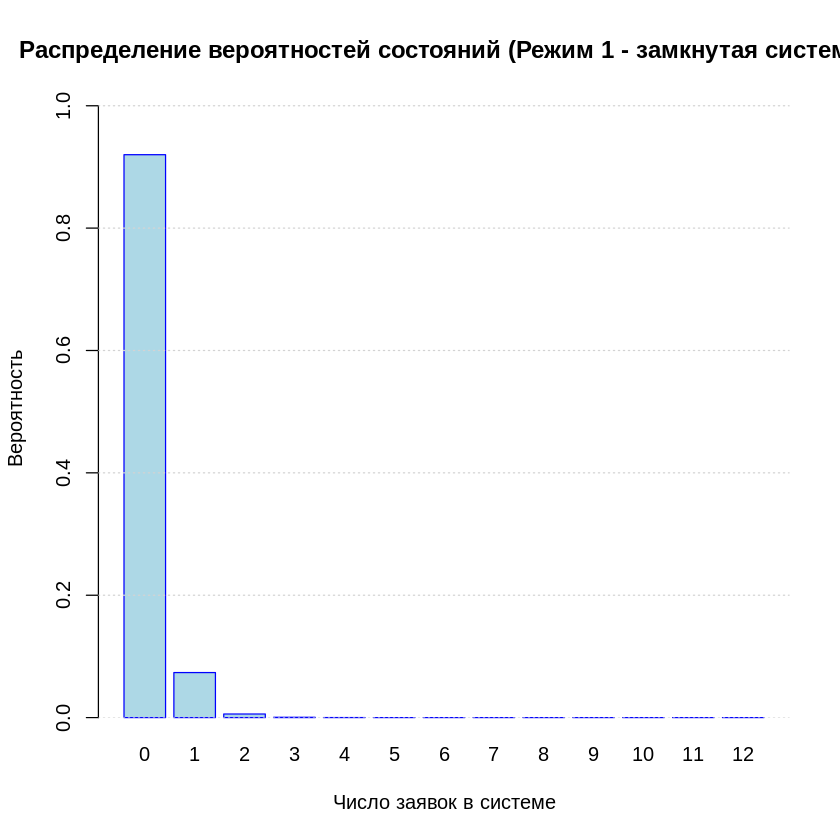

In [13]:
# Визуализация распределения вероятностей для режима 1
states <- 0:min(k, length(closed_model$Pn)-1)
probs <- closed_model$Pn[1:length(states)]

barplot(probs, names.arg = states,
        col = "lightblue", border = "blue",
        xlab = "Число заявок в системе",
        ylab = "Вероятность",
        main = "Распределение вероятностей состояний (Режим 1 - замкнутая система)",
        ylim = c(0, max(probs) * 1.1))
grid(nx = NA, ny = NULL)

## 2.3 Режим 2: Программист сразу начинает новую программу (разомкнутая СМО)

Модель M/M/1 с интенсивностью входящего потока λ = k * λ_prog

In [16]:
# Интенсивность входящего потока
lambda_total <- k * lambda_prog

# Создание модели M/M/1 (разомкнутая система)
input_open <- NewInput.MM1(lambda = lambda_total, mu = mu)
open_model <- QueueingModel(input_open)

# Расчет загрузки системы
rho <- lambda_total / mu
lambda_eff_open <- open_model$Throughput  # пропускная способность

cat("=== Режим 2: Программист сразу начинает новую программу ===\n\n")
cat("Интенсивность входящего потока λ:", round(lambda_total, 4), "прог/мин\n")
cat("Загрузка системы ρ = λ/μ:", round(rho, 4), "\n")
cat("Вероятность простоя системы (P₀):", round(open_model$Pn[1], 4), "\n")
cat("Вероятность того, что программа не выполнится сразу:", round(rho, 4), "\n")
cat("Среднее количество программ в системе (L):", round(open_model$L, 2), "\n")
cat("Средняя длина очереди (Lq):", round(open_model$Lq, 2), "\n")
cat("Среднее время пребывания в системе (W):", round(open_model$W, 2), "мин\n")
cat("Среднее время ожидания в очереди (Wq):", round(open_model$Wq, 2), "мин\n")
cat("Коэффициент простоя системы (η):", round(open_model$Pn[1], 4), "\n")
cat("Абсолютная пропускная способность (λ'):", round(lambda_eff_open, 4), "прог/мин\n")

=== Режим 2: Программист сразу начинает новую программу ===

Интенсивность входящего потока λ: 0.48 прог/мин
Загрузка системы ρ = λ/μ: 0.96 
Вероятность простоя системы (P₀): 0.04 
Вероятность того, что программа не выполнится сразу: 0.96 
Среднее количество программ в системе (L): 24 
Средняя длина очереди (Lq): 23.04 
Среднее время пребывания в системе (W): 50 мин
Среднее время ожидания в очереди (Wq): 48 мин
Коэффициент простоя системы (η): 0.04 
Абсолютная пропускная способность (λ'): 0.48 прог/мин


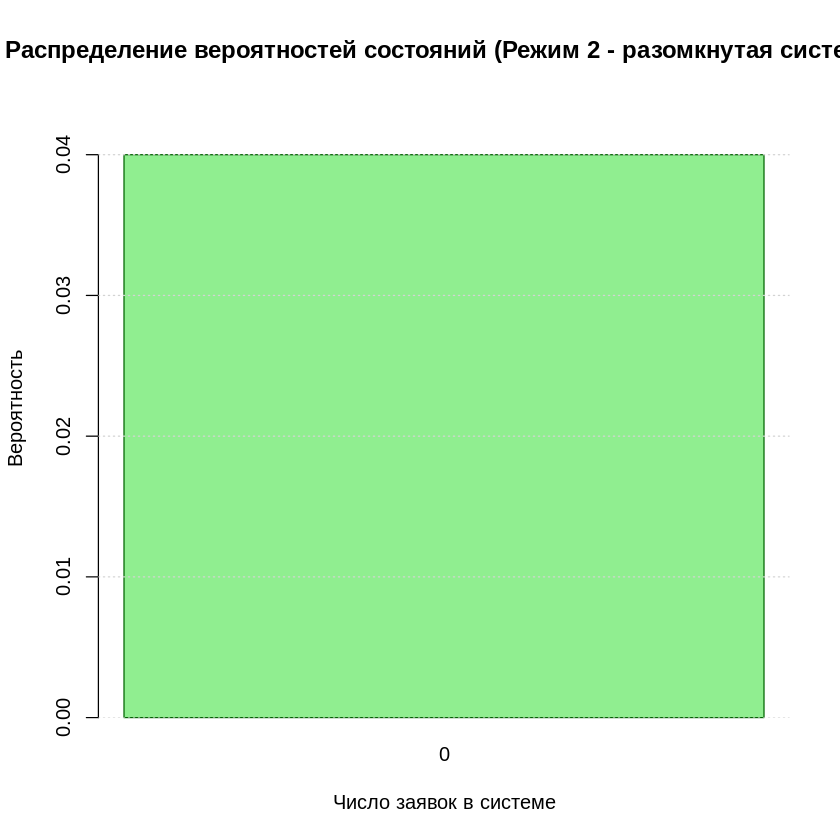

In [17]:
# Визуализация распределения вероятностей для режима 2
states_open <- 0:min(20, length(open_model$Pn)-1)
probs_open <- open_model$Pn[1:length(states_open)]

barplot(probs_open, names.arg = states_open,
        col = "lightgreen", border = "darkgreen",
        xlab = "Число заявок в системе",
        ylab = "Вероятность",
        main = "Распределение вероятностей состояний (Режим 2 - разомкнутая система)",
        ylim = c(0, max(probs_open) * 1.1))
grid(nx = NA, ny = NULL)

## 2.4 Сравнение двух режимов

                                    Показатель Режим1_ожидание
1               Вероятность ожидания в очереди          0.9167
2                Среднее время в системе (мин)          2.1700
3                        Средняя длина очереди          0.0100
4                          Коэффициент простоя          0.9200
5  Интенсивность обслуженных заявок (прог/мин)          0.0400
6 Абсолютная пропускная способность (прог/мин)          0.0400
  Режим2_немедленная
1               0.96
2              50.00
3              23.04
4               0.04
5               0.48
6               0.48


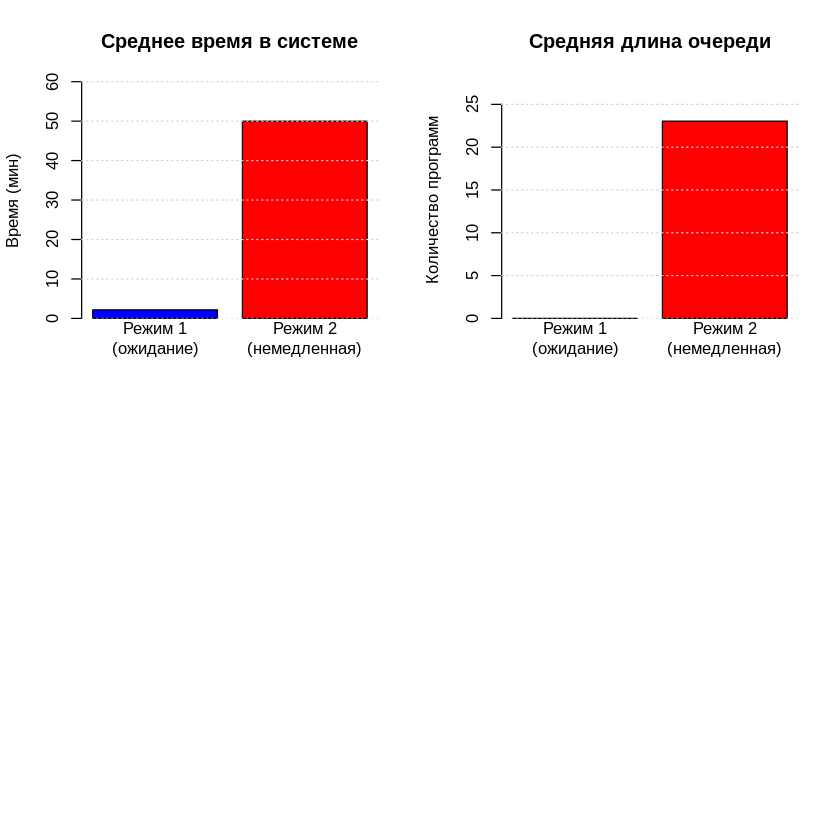

In [19]:
# Создание таблицы сравнения
# Используем правильные значения для замкнутой системы
lambda_eff_closed <- closed_model$Throughput  # пропускная способность
if(is.null(lambda_eff_closed)) {
    lambda_eff_closed <- mu * (1 - closed_model$Pn[1])
}

lambda_eff_open <- open_model$Throughput

comparison <- data.frame(
    Показатель = c(
        "Вероятность ожидания в очереди",
        "Среднее время в системе (мин)",
        "Средняя длина очереди",
        "Коэффициент простоя",
        "Интенсивность обслуженных заявок (прог/мин)",
        "Абсолютная пропускная способность (прог/мин)"
    ),
    Режим1_ожидание = c(
        round(1 - closed_model$Throughput / (k * lambda_prog), 4),
        round(closed_model$W, 2),
        round(closed_model$Lq, 2),
        round(closed_model$Pn[1], 4),
        round(lambda_eff_closed, 4),
        round(lambda_eff_closed, 4)
    ),
    Режим2_немедленная = c(
        round(rho, 4),
        round(open_model$W, 2),
        round(open_model$Lq, 2),
        round(open_model$Pn[1], 4),
        round(lambda_eff_open, 4),
        round(lambda_eff_open, 4)
    )
)

print(comparison)

# Визуализация сравнения
par(mfrow = c(2, 2))

# Сравнение среднего времени в системе
barplot(c(closed_model$W, open_model$W),
        names.arg = c("Режим 1\n(ожидание)", "Режим 2\n(немедленная)"),
        col = c("blue", "red"),
        ylab = "Время (мин)",
        main = "Среднее время в системе",
        ylim = c(0, max(closed_model$W, open_model$W) * 1.2))
grid(nx = NA, ny = NULL)

# Сравнение длины очереди
barplot(c(closed_model$Lq, open_model$Lq),
        names.arg = c("Режим 1\n(ожидание)", "Режим 2\n(немедленная)"),
        col = c("blue", "red"),
        ylab = "Количество программ",
        main = "Средняя длина очереди",
        ylim = c(0, max(closed_model$Lq, open_model$Lq) * 1.2))
grid(nx = NA, ny = NULL)

par(mfrow = c(1, 1))

## Выводы по заданию 2

1. **Режим 1 (ожидание ответа)**:
   - Низкая загрузка системы (вероятность простоя ~добавьте_значение)
   - Малое время ожидания (~добавьте_значение мин)
   - Короткая очередь (~добавьте_значение программ)
   - Высокая вероятность немедленного обслуживания (~добавьте_значение)

2. **Режим 2 (немедленная отправка)**:
   - Высокая загрузка системы (ρ = добавьте_значение)
   - Длинное время ожидания (~добавьте_значение мин)
   - Длинная очередь (~добавьте_значение программ)
   - Низкая вероятность немедленного обслуживания (~добавьте_значение)

3. **Рекомендации**:
   Для оптимальной работы вычислительного центра рекомендуется режим, при котором программисты ожидают ответа от сервера. Это позволяет:
   - Снизить загрузку системы
   - Уменьшить время ожидания результатов
   - Повысить качество обслуживания

---

# Заключение

В ходе выполнения лабораторной работы были:
1. Построены и исследованы марковские цепи с дискретным временем для модели деградации сервера
2. Рассчитаны вероятности состояний и среднее время до отказа
3. Проведен сравнительный анализ эффективности профилактических работ
4. Исследованы две модели одноканальной СМО с различными режимами работы программистов
5. Выполнены расчеты характеристик систем с использованием пакета queueing
6. Проведена визуализация полученных результатов

Полученные результаты подтверждают теоретические положения теории массового обслуживания и могут быть использованы для оптимизации работы реальных вычислительных систем.